# Bias Analysis - Study3

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import matplotlib.colors as mcolors
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from scipy import stats
import itertools
import string

In [2]:
ageRisk = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

In [3]:
ageRisk.shape

(962, 12)

## Resolving ETFs 

In [4]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'cond', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [5]:
ageRisk_unique_equities = ageRisk[ageRisk["asset_type"] == "EQUITY"]["ticker_symbol"].unique()
equities = ageRisk_unique_equities

In [6]:
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

study1_etf_data = pd.read_csv('../study1/etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0, low_memory=False)
study1_fund_data = pd.read_csv('../study1/mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0, low_memory=False)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
study1_etf_data = prepare_refinitiv_dataset(study1_etf_data, cols_refinitiv)
study1_etfs = study1_etf_data['fund'].unique()

study1_fund_data = study1_fund_data.iloc[:,:-2]
study1_fund_data = prepare_refinitiv_dataset(study1_fund_data, cols_refinitiv)
study1_funds = study1_fund_data['fund'].unique()

study2b_fund_data = pd.read_csv('../study2b/data/refinitiv/funds_refinitiv_study2b.csv', index_col=0, low_memory=False)
study2b_fund_data = prepare_refinitiv_dataset(study2b_fund_data, cols_refinitiv)
study2b_funds = study2b_fund_data['fund'].unique()

study2a_addition_data = pd.read_csv('../study1/etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
study2a_addition_data = prepare_refinitiv_dataset(study2a_addition_data, cols_refinitiv)
study2a_additions = study2a_addition_data['fund'].unique()

prev_etfs = np.union1d(np.union1d(study1_etfs, study2b_funds), study2a_additions ) 
prev_funds = np.union1d(np.union1d(study1_funds, study2b_funds), study2a_additions)

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector']
study2a_fund_data = pd.read_csv('../study2a/data/refinitiv/funds_refinitiv_study2a.csv', index_col=0, low_memory=False)
study2a_fund_data = prepare_refinitiv_dataset(study2a_fund_data, cols_refinitiv)
study2a_fund_data = study2a_fund_data[study2a_fund_data['fund'].isin(new_funds)]

study2a_etf_data = pd.read_csv('../study2a/data/refinitiv/etfs_refinitiv_study2a.csv', index_col=0)
study2a_etf_data = prepare_refinitiv_dataset(study2a_etf_data, cols_refinitiv)
study2a_etf_data = study2a_etf_data[study2a_etf_data['fund'].isin(new_etfs)]

prev_etf_data = pd.concat([
    study1_etf_data, 
    study2b_fund_data,
    study2a_addition_data,
    study2a_etf_data], ignore_index=True)

prev_fund_data = pd.concat([
    study1_etf_data, 
    study1_fund_data, 
    study2a_addition_data, 
    study2b_fund_data,
    study2a_etf_data,
    study2a_fund_data], ignore_index=True)

prev_etfs = prev_etf_data['fund'].unique()
prev_funds = prev_fund_data['fund'].unique()

new_etfs = [item for item in etfs if item not in prev_etfs]
new_funds = [item for item in funds if item not in prev_funds]

In [7]:
new_etfs

['ESGV',
 'EAGG',
 'DSI',
 'WOMN',
 'BGRN',
 'GRNB',
 'ESGD',
 'ACWI',
 'CRBN',
 'KRMA',
 'EFIV',
 'SUSL',
 'VCEB',
 'SUSA',
 'MOO',
 'VGIT',
 'ESGU',
 'SDG',
 'ESGW',
 'PHO',
 'BIV',
 'DBA',
 'EWZ',
 'JNK',
 'BKLN',
 'SUSC',
 'VSGX',
 'ESGE',
 'SPYX']

In [8]:
resStr_etf = ""
os = ['BGRN', 'ESGD', 'ACWI', 'KRMA', 'SUSL', 'VGIT', 'ESGU', 'SDG', 'PHO', 'SUSC', 'ESGE']
ks = ['ESGV', 'EAGG', 'WOMN', 'GRNB', 'CRBN', 'EFIV', 'VCEB', 'SUSA', 'BKLN', 'VSGX', 'SPYX']
s = ['ESGW']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    elif etf in s:
        resStr_etf += f'{etf}.S;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;VGIT.O;ESGU.O;SDG.O;ESGW.S;PHO.O;BIV;DBA;EWZ;JNK;BKLN.K;SUSC.O;VSGX.K;ESGE.O;SPYX.K;'

In [9]:
new_funds

[nan,
 'TISCX',
 'CGAFX',
 'TICRX',
 'TICSX',
 'VFTAX',
 'CSIIX',
 'CSIEX',
 'PRILX',
 'CFGRX',
 'DSEFX',
 'TICCX',
 'PAXIX',
 'CIBFX',
 'CCPIX',
 'TSBRX',
 'TSBIX',
 'PRFDX',
 'CGAEX',
 'IEMGX',
 'PRFIX',
 'CGRIX',
 'CAAFX',
 'TRIIX',
 'PXWEX']

In [10]:
resStr_mutualFunds = "";
for fund in new_funds:
        resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

'nan.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

In [11]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

'ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;VGIT.O;ESGU.O;SDG.O;ESGW.S;PHO.O;BIV;DBA;EWZ;JNK;BKLN.K;SUSC.O;VSGX.K;ESGE.O;SPYX.K;nan.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

### Prepare ESG strings

In [12]:
resStr_equities = ""
os = ['AAPL', 'MSFT', 'TSLA', 'META', 'AMZN', 'GOOGL', 'NVDA', 'BYND', 'MRNA', 'DKNG', 'FSLR', 
      'ADBE', 'TTD', 'AMD', 'CSX', 'ETSY']
ks = ['PLTR', 'TDOC', 'HASI',]
pk = ['VWDRY']
for equity in equities:
    if equity in os:
        resStr_equities += f'{equity}.O;'
    elif equity in ks:
        resStr_equities += f'{equity}.K;'
    elif equity in pk:
        resStr_equities += f'{equity}.PK;'
    else:
        resStr_equities += f'{equity};'
resStr_equities

'JNJ;AAPL.O;MSFT.O;KO;PG;TSLA.O;META.O;SQ;AMZN.O;GOOGL.O;NVDA.O;GME;BYND.O;PLTR.K;MRNA.O;NIO;DKNG.O;AMC;NEE;WM;MMM;FSLR.O;VWDRY.PK;ADBE.O;NKE;AWK;BAC;TDOC.K;CRM;BEP;T;LC;TTD.O;PFE;AMD.O;HASI.K;DLR;CSX.O;UL;ETSY.O;BXP;ARE;AMT;BG;XYL;NTR;'

In [13]:
resStr_etf_all = ""
os = ['BGRN', 'ESGD', 'ACWI', 'KRMA', 'SUSL', 'VGIT', 'ESGU', 'SDG', 'PHO', 'SUSC', 'ESGE',
     'MCHI', 'IXUS', 'ACWX', 'DVY', 'CIBR',
      'ACWX', 'DVY', 'VCLT', 'IXUS', 'IGOV',
      'QQQ', 'SHY', 'VXUS', 'ICLN', 'BND', 'BOTZ', 'IEF', 'TLT', 'SOXX', 'ANGL', 'VCSH', 'REIT']
ks = ['ESGV', 'EAGG', 'WOMN', 'GRNB', 'CRBN', 'EFIV', 'VCEB', 'SUSA', 'BKLN', 'VSGX', 'SPYX',
     'SCHK', 'REET', 'INDA', 'ARKF', 'SCHD', 'USMV', 'SCHA', 'IA', 'IAGG', 'GOVT', 'IEFA', 'ARKK', 
      'ARKW', 'ARKG', 'NOBL', 'IEMG', 'SCHH']
s = ['ESGW']
for etf in etfs:
    if etf in os:
        resStr_etf_all += f'{etf}.O;'
    elif etf in ks:
        resStr_etf_all += f'{etf}.K;'
    elif etf in s:
        resStr_etf_all += f'{etf}.S;'
    else:
        resStr_etf_all += f'{etf};'
resStr_etf_all

'VOO;GOVT.K;VNQ;BND.O;VIG;AGG;IEF.O;IAU;DBC;QQQ.O;VTI;SPY;ICLN.O;ARKK.K;VWO;VGT;XLV;ARKG.K;ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;FAN;VGIT.O;NOBL.K;LQD;VT;MUB;EEM;ESGU.O;SDG.O;TAN;ESGW.S;PHO.O;EFA;BIV;DVY.O;GLD;XLK;VYM;HYG;VB;USO;DBA;MCHI.O;EWZ;JNK;BKLN.K;BOTZ.O;TLT.O;SUSC.O;VSGX.K;ESGE.O;PBW;SPYX.K;'

In [14]:
resStr_mutualFunds_all = "";
delisted = ['VTWSX', 'VDAIX']
for fund in funds:
    if fund in delisted:
        resStr_mutualFunds_all += f'{fund}.O^K19;'
    else:
        resStr_mutualFunds_all += f'{fund}.O;'
resStr_mutualFunds_all

'VFINX.O;VTSAX.O;VSMGX.O;nan.O;FCNTX.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;PRBLX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;VFIAX.O;SWPPX.O;VTSMX.O;VBTLX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

In [15]:
esg_str = resStr_equities + resStr_etf_all + resStr_mutualFunds_all
esg_str

'JNJ;AAPL.O;MSFT.O;KO;PG;TSLA.O;META.O;SQ;AMZN.O;GOOGL.O;NVDA.O;GME;BYND.O;PLTR.K;MRNA.O;NIO;DKNG.O;AMC;NEE;WM;MMM;FSLR.O;VWDRY.PK;ADBE.O;NKE;AWK;BAC;TDOC.K;CRM;BEP;T;LC;TTD.O;PFE;AMD.O;HASI.K;DLR;CSX.O;UL;ETSY.O;BXP;ARE;AMT;BG;XYL;NTR;VOO;GOVT.K;VNQ;BND.O;VIG;AGG;IEF.O;IAU;DBC;QQQ.O;VTI;SPY;ICLN.O;ARKK.K;VWO;VGT;XLV;ARKG.K;ESGV.K;EAGG.K;DSI;WOMN.K;BGRN.O;GRNB.K;ESGD.O;ACWI.O;CRBN.K;KRMA.O;EFIV.K;SUSL.O;VCEB.K;SUSA.K;MOO;FAN;VGIT.O;NOBL.K;LQD;VT;MUB;EEM;ESGU.O;SDG.O;TAN;ESGW.S;PHO.O;EFA;BIV;DVY.O;GLD;XLK;VYM;HYG;VB;USO;DBA;MCHI.O;EWZ;JNK;BKLN.K;BOTZ.O;TLT.O;SUSC.O;VSGX.K;ESGE.O;PBW;SPYX.K;VFINX.O;VTSAX.O;VSMGX.O;nan.O;FCNTX.O;TISCX.O;CGAFX.O;TICRX.O;TICSX.O;VFTAX.O;PRBLX.O;CSIIX.O;CSIEX.O;PRILX.O;CFGRX.O;DSEFX.O;VFIAX.O;SWPPX.O;VTSMX.O;VBTLX.O;TICCX.O;PAXIX.O;CIBFX.O;CCPIX.O;TSBRX.O;TSBIX.O;PRFDX.O;CGAEX.O;IEMGX.O;PRFIX.O;CGRIX.O;CAAFX.O;TRIIX.O;PXWEX.O;'

In [16]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [92]:
cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'industry_group']

study3_refinitiv_data = pd.read_csv('./data/refinitiv/refinitiv_study3.csv', index_col=0, low_memory=False)
study3_refinitiv_data = prepare_refinitiv_dataset(study3_refinitiv_data, cols_refinitiv)
study3_refinitiv_data = study3_refinitiv_data[study3_refinitiv_data['fund'].isin(new_funds)]
study3_refinitiv_data = study3_refinitiv_data.drop('industry_group', axis=1)

etf_data = pd.concat([prev_etf_data, study3_refinitiv_data], ignore_index=True)
etf_data.to_csv('./data/refinitiv/complete/etf_data.csv')

fund_data = pd.concat([prev_fund_data, study3_refinitiv_data], ignore_index=True)
fund_data.to_csv('./data/refinitiv/complete/fund_data.csv')

In [18]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df, select_cols):
    df = df.merge(etf_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors)
    #return df
    return resolve_layer2(df, select_cols)

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('../study1/benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))


In [19]:
ageRisk_resolved.head()

,ai,age,risk-taking,cond,iteration,ticker_symbol,amount_to_invest,weight_x,sector,asset_type,...,code_l2,equity_l2,symbol_l2,#shares_l2,weight_l2,country_l2,type_l2,economic_sector_l2,weight,country
0,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.022664,UNITED STATES
1,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.019490,UNITED STATES
2,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Consumer Cyclical,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.009311,UNITED STATES
3,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.009018,UNITED STATES
4,ChatGPT,15,averse,control,0,VOO,3000.0,0.3,Technology,ETF,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.006152,UNITED STATES


In [20]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [21]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    cond = df['cond'].unique()
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'iteration', 'cond', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'cond', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [22]:
mpl.rcParams['font.size'] = 14  # Change the size to your preference
mpl.rcParams['font.sans-serif'] = 'Arial'

In [23]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        d = group_values.mean() - benchmark
        print(f'group: {group_name} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 2)} d: {round(d, 2)}')

def show_ttest_ind(raw, column, groups):
    unique_groups = raw[groups].unique()
    if len(unique_groups) != 2:
        print('Error occured calculating the t-test between the groups.')
        return

    group1, group2 = unique_groups
    data1 = raw[raw[groups] == group1][column].dropna()
    data2 = raw[raw[groups] == group2][column].dropna()
    print(stats.ttest_ind(data1, data2))
    t_stat, p_value = stats.ttest_ind(data1, data2)
    print(f'group1: {group1} and group2: {group2} got t: {round(t_stat,2)}, p_value: {round(p_value,4)}, df: {len(data1) + len(data2) - 2}')
    

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    if group2:
        show_anova(raw, column, group1, group2, onlyGroup)
    else:
        show_ttest_ind(raw, column, group1)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2, onlyGroup)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['cond', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

ageRisk_resolved['cond'] = ageRisk_resolved['cond'].replace({'control': 'Control prompt','engineered': 'Goal prompt'})
ageRisk['cond'] = ageRisk['cond'].replace({'control': 'Control prompt','engineered': 'Goal prompt'})


## Geographic cluster risk

In [24]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out due to wrong labeling
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)
(484523, 35)


TtestResult(statistic=3.825852813693654, pvalue=0.00018018326482172525, df=178.0)
group1: Control prompt and group2: Goal prompt got t: 3.83, p_value: 0.0002, df: 178
group: ('Control prompt',) got t: 48.4 p_value: 0.0 dfs: 89 benchmark: 58.96 d: 36.21
group: ('Goal prompt',) got t: 21.23 p_value: 0.0 dfs: 89 benchmark: 58.96 d: 30.08
means:
cond
Control prompt    95.18
Goal prompt       89.04
Name: weight, dtype: float64
stds:
cond
Control prompt     7.10
Goal prompt       13.44
Name: weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: weight, dtype: int64


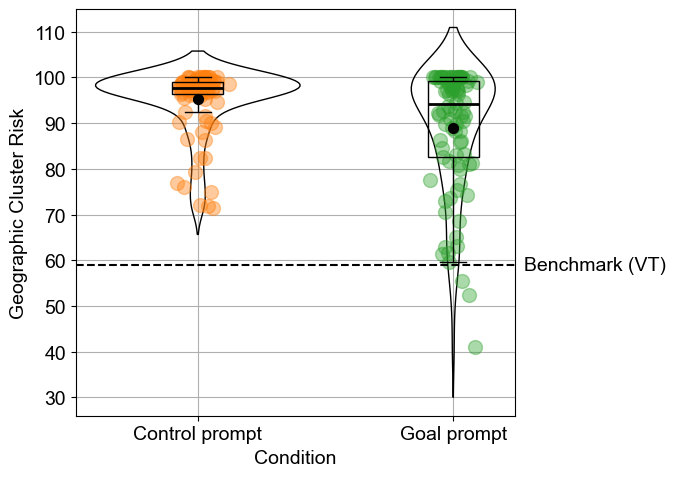

In [25]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond',
    'study3_geoRisk'
)

In [26]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'cond', 'risk-taking')

                sum_sq     df         F   PR(>F)
label      2033.492313    5.0  3.498992  0.00487
Residual  20224.546078  174.0       NaN      NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
          group1                    group2          meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------
 (Control prompt, averse) (Control prompt, neutral)  -1.6454 0.9915  -9.6672  6.3765  False
 (Control prompt, averse) (Control prompt, seeking)  -2.7021 0.9266  -10.724  5.3197  False
 (Control prompt, averse)     (Goal prompt, averse)  -7.4217 0.0875 -15.4436  0.6001  False
 (Control prompt, averse)    (Goal prompt, neutral)   -9.616 0.0089 -17.6379 -1.5942   True
 (Control prompt, averse)    (Goal prompt, seeking)  -5.7012 0.3198 -13.7231  2.3206  False
(Control prompt, neutral) (Control prompt, seeking)  -1.0568  0.999  -9.0786  6.9651  False
(Control prompt, neutral)

In [27]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'cond', 'age')

                sum_sq     df         F   PR(>F)
label      2471.763253    5.0  4.347325  0.00094
Residual  19786.275138  174.0       NaN      NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1               group2        meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------
(Control prompt, 15) (Control prompt, 30)  -1.0123 0.9991  -8.9468  6.9221  False
(Control prompt, 15) (Control prompt, 50)   -2.585 0.9359 -10.5195  5.3495  False
(Control prompt, 15)    (Goal prompt, 15)  -4.0125 0.6918 -11.9469   3.922  False
(Control prompt, 15)    (Goal prompt, 30)   -7.239 0.0958 -15.1735  0.6954  False
(Control prompt, 15)    (Goal prompt, 50) -10.7373 0.0019 -18.6718 -2.8029   True
(Control prompt, 30) (Control prompt, 50)  -1.5727 0.9928  -9.5071  6.3618  False
(Control prompt, 30)    (Goal prompt, 15)  -3.0001  0.885 -10.9346  4.9343  False
(Control prompt, 30)    (Goal pro

## Sector cluster risk

In [28]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before
sec = calculate_concentration(sec, group_cols)

(9621, 15)
(481132, 35)


TtestResult(statistic=-0.21438678656130883, pvalue=0.8304908456895143, df=178.0)
group1: Control prompt and group2: Goal prompt got t: -0.21, p_value: 0.8305, df: 178
group: ('Control prompt',) got t: 11.72 p_value: 0.0 dfs: 89 benchmark: 0.15 d: 0.18
group: ('Goal prompt',) got t: 9.1 p_value: 0.0 dfs: 89 benchmark: 0.15 d: 0.19
means:
cond
Control prompt    0.33
Goal prompt       0.34
Name: concentration, dtype: float64
stds:
cond
Control prompt    0.15
Goal prompt       0.19
Name: concentration, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: concentration, dtype: int64


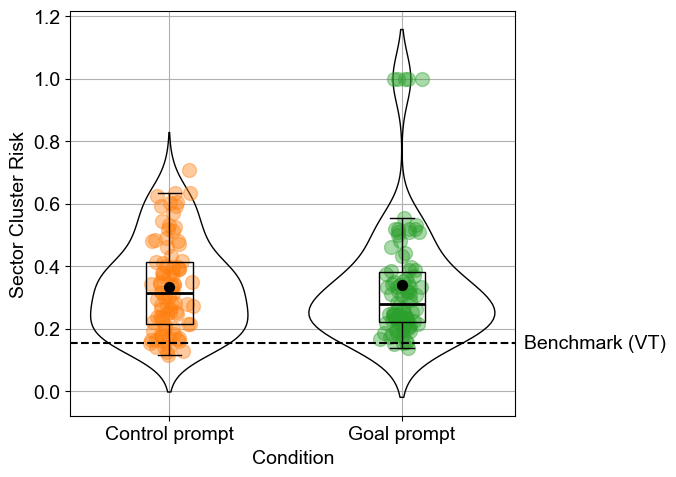

In [29]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond',
    'study3_sectorRisk'
)

In [30]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'cond', 'risk-taking')

            sum_sq     df         F    PR(>F)
label     0.795557    5.0  6.230754  0.000024
Residual  4.443345  174.0       NaN       NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
          group1                    group2          meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------------
 (Control prompt, averse) (Control prompt, neutral)   0.0982 0.1687 -0.0207  0.2171  False
 (Control prompt, averse) (Control prompt, seeking)   0.2029    0.0   0.084  0.3218   True
 (Control prompt, averse)     (Goal prompt, averse)   0.0479  0.855  -0.071  0.1668  False
 (Control prompt, averse)    (Goal prompt, neutral)   0.1144 0.0667 -0.0045  0.2333  False
 (Control prompt, averse)    (Goal prompt, seeking)   0.1553 0.0031  0.0364  0.2742   True
(Control prompt, neutral) (Control prompt, seeking)   0.1047 0.1192 -0.0142  0.2236  False
(Control prompt, neutral)     (Goal prompt,

In [31]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'cond', 'age')

            sum_sq     df         F    PR(>F)
label     0.137885    5.0  0.940677  0.456073
Residual  5.101017  174.0       NaN       NaN
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2        meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------
(Control prompt, 15) (Control prompt, 30)  -0.0316 0.9801  -0.159 0.0958  False
(Control prompt, 15) (Control prompt, 50)  -0.0862 0.3751 -0.2136 0.0412  False
(Control prompt, 15)    (Goal prompt, 15)   -0.055 0.8139 -0.1824 0.0724  False
(Control prompt, 15)    (Goal prompt, 30)  -0.0174 0.9987 -0.1448   0.11  False
(Control prompt, 15)    (Goal prompt, 50)  -0.0289 0.9866 -0.1563 0.0985  False
(Control prompt, 30) (Control prompt, 50)  -0.0547 0.8181 -0.1821 0.0727  False
(Control prompt, 30)    (Goal prompt, 15)  -0.0235 0.9948 -0.1509 0.1039  False
(Control prompt, 30)    (Goal prompt, 30)   0.0141 0.9996 -0.1

## Concentration Map

In [32]:
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(474149, 35)
             sum_sq      df          F         PR(>F)
label     17.211725    13.0  109.07745  1.373028e-232
Residual  30.417753  2506.0        NaN            NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0143 0.9944 -0.0247  0.0533  False
           Academic & Educational Services                     Communication Services   0.0186 0.9451 -0.0203  0.0576  False
           Academic & Educational Services                          Consumer Cyclical   0.2164    0.0  0.1775  0.2554   True
           Academic & Educational Services                     Consumer Non

(9485, 15)


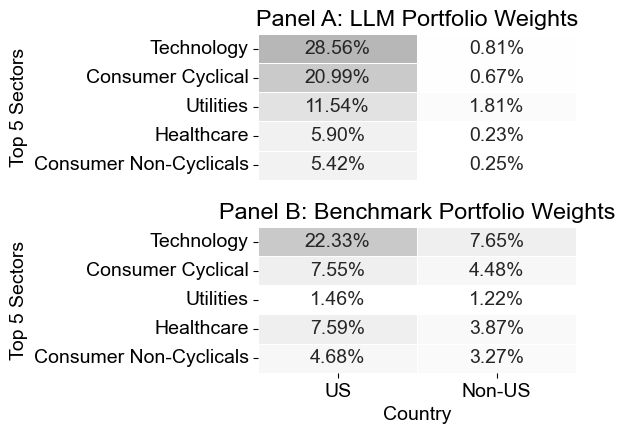

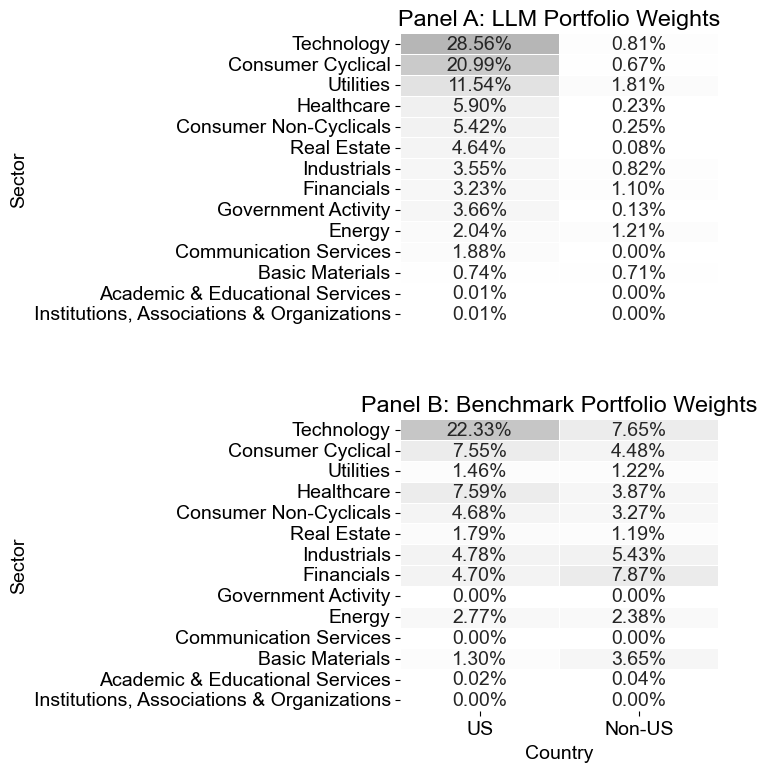

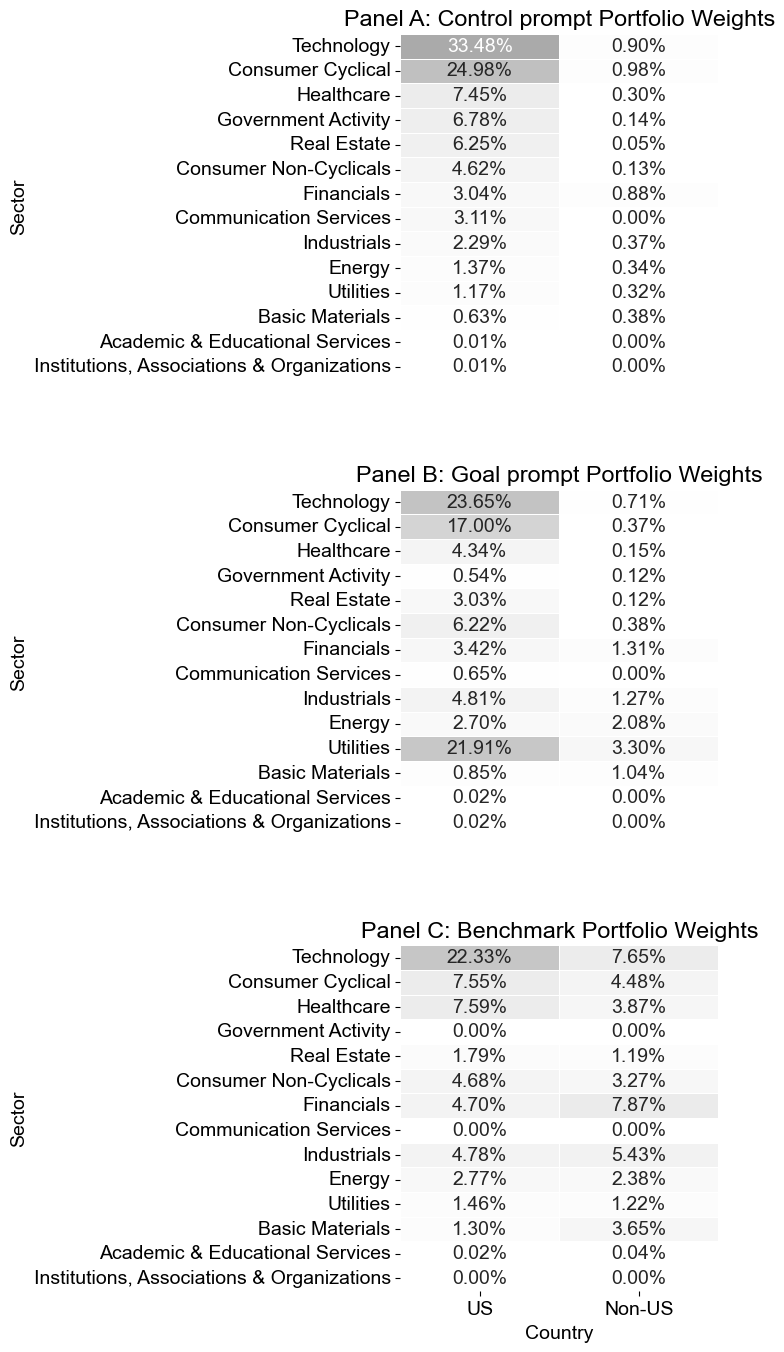

In [33]:
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

import numpy as np

def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    y_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels("Country", y_label)
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study3_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study3_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study3_concentration_map_details', False, 4, 14)

In [34]:
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()
    combined_df = combined_df.sort_values(by='type', ascending=False)
    replacements = {'Control prompt': 'Control Prompt', 'Goal prompt': 'Goal Prompt'}
    combined_df['type'] = combined_df['type'].replace(replacements)

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    x_label = 'Top 5 Sectors' if show_top else 'Sector'
    g.set_axis_labels(x_label, "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

(9485, 15)


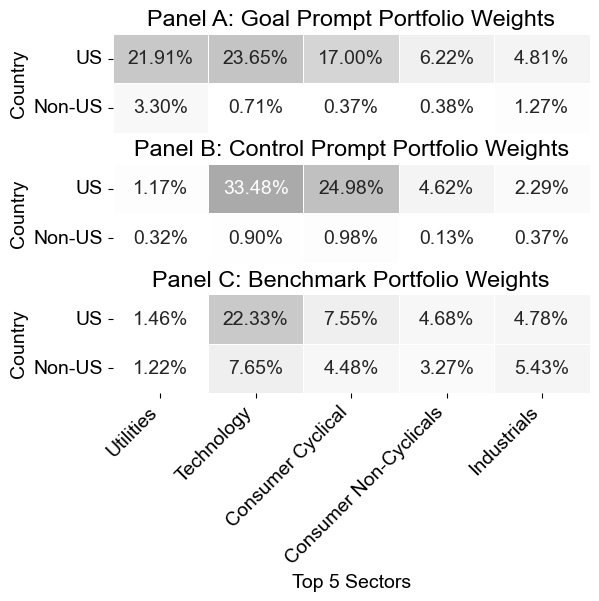

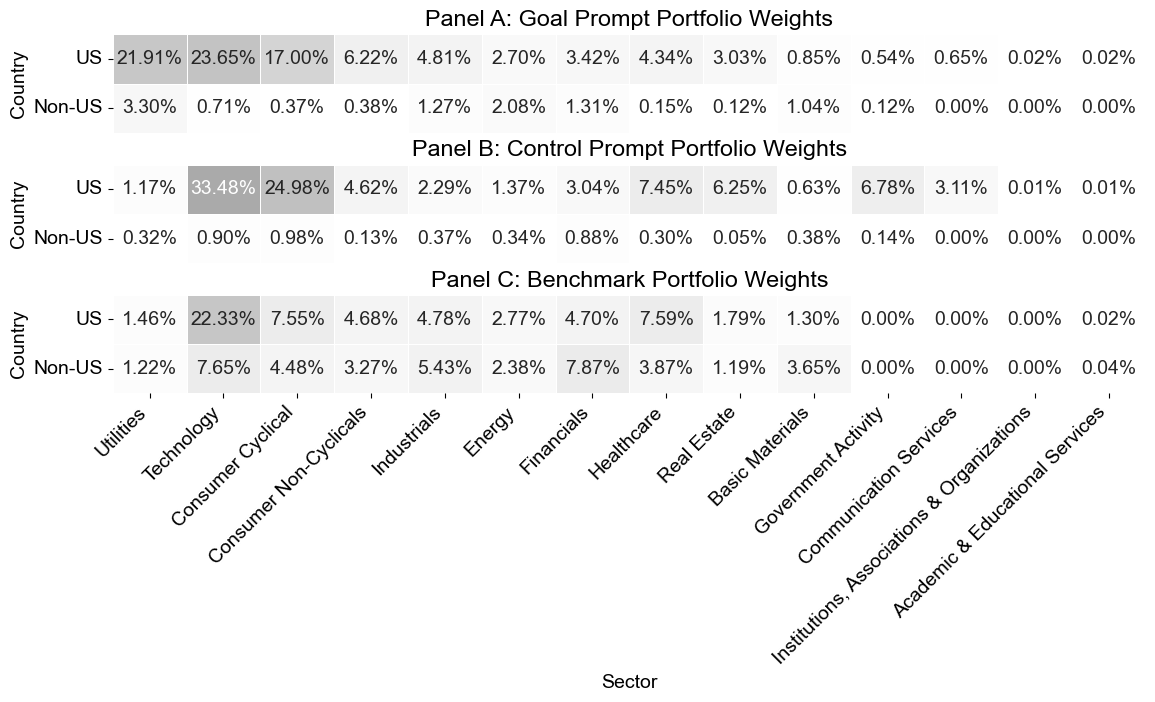

In [35]:
benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study3_overview_concentration_map_horizontal', True, 6, 4)
show_faceted_heatmap(combined_details, 'study3_details_concentration_map_horizontal', False, 13, 4)

In [36]:
calc_overview(sec_ov, 'weight','weight','cond', 'sector')
show_matched_ttest(sec_ov[sec_ov['cond']=='Goal prompt'], 'sector', bench_sec_ov)

             sum_sq      df          F         PR(>F)
label     20.938025    27.0  72.401534  4.576008e-289
Residual  26.691453  2492.0        NaN            NaN
                                                      Multiple Comparison of Means - Tukey HSD, FWER=0.05                                                       
                           group1                                                       group2                            meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------------------------------------------
           (Control prompt, Academic & Educational Services)                            (Control prompt, Basic Materials)   0.0099    1.0 -0.0475  0.0673  False
           (Control prompt, Academic & Educational Services)                     (Control prompt, Communication Services)    0.031 0.9697 -0.0264  0.0884  False
           (Control prompt, Acade

In [37]:
combined['cond'].unique()

array(['Control prompt', 'Goal prompt', 'VT'], dtype=object)

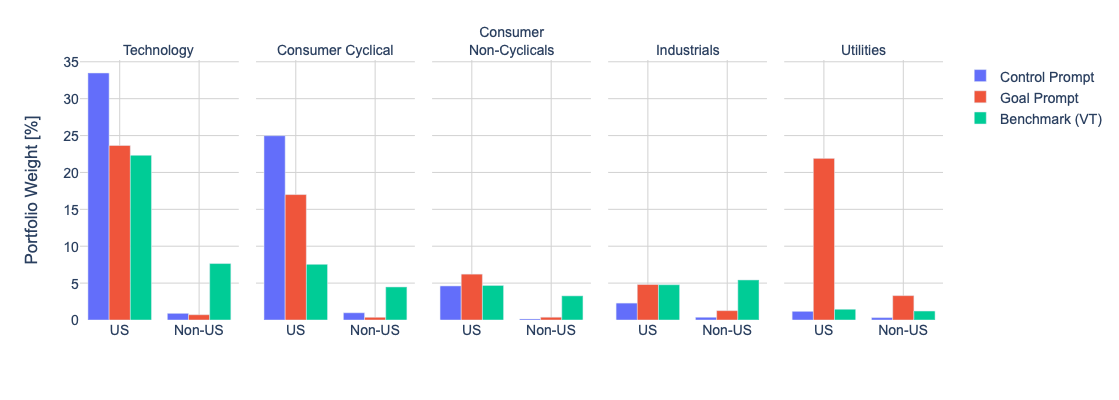

In [78]:
import plotly_express as px
import kaleido

selected_sectors = ['Technology', 'Consumer Cyclical', 'Consumer Non-Cyclicals', 'Industrials', 'Utilities']
replacements = {'Control prompt': 'Control Prompt', 'Goal prompt': 'Goal Prompt', 'VT': 'Benchmark (VT)'}
combined['cond'] = combined['cond'].replace(replacements)
combined_grouped = combined.groupby(['sector', 'country', 'cond'])['weight'].mean().reset_index()
filtered_df = combined_grouped[combined_grouped['sector'].isin(selected_sectors)]
filtered_df = filtered_df.copy()
filtered_df['weight'] = filtered_df['weight'] * 100


fig = px.bar(filtered_df, x="country", y="weight", facet_col="sector", barmode='group', color="cond", color_continuous_scale='Greys', 
             category_orders={'sector': selected_sectors,
                             'cond':['Control Prompt', 'Goal Prompt', 'Benchmark (VT)']}
            )
fig.update_layout(
    xaxis={'categoryorder':'array', 'categoryarray':['US','Non-US']}, 
    legend_title='', 
    yaxis_title='Portfolio Weight [%]')
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey')
fig.for_each_annotation(lambda a: a.update(text = a.text.replace("sector=", "")))
for annotation in fig.layout.annotations:
    if annotation.text == 'Consumer Non-Cyclicals':
        annotation.text = 'Consumer<br>Non-Cyclicals'
fig.update_layout()
fig.update_xaxes(tickangle=0, title=None)
fig.update_layout(autosize=False, width=800, height=400, font=dict(family="Arial", size=14))

fig.write_image('./figures/concentration.png')

fig.show()

## Active investment allocation risk

In [39]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]

ter_data_study2b = pd.read_csv('../study2b/data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study2a = pd.read_csv('../study2a/data/refinitiv/ter_study2a.csv', index_col=0)
ter_data_study2a = ter_data_study2a.iloc[1:].reset_index()
ter_data_study2a.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data_study3 = pd.read_csv('./data/refinitiv/ter_study3.csv', index_col=0)
ter_data_study3 = ter_data_study3.iloc[1:].reset_index()
ter_data_study3.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b, ter_data_study2a, ter_data_study3], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [40]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

TtestResult(statistic=-7.870615959988916, pvalue=3.3164338859308573e-13, df=178.0)
group1: Control prompt and group2: Goal prompt got t: -7.87, p_value: 0.0, df: 178
group: ('Control prompt',) got t: 18.51 p_value: 0.0 dfs: 89 benchmark: 0 d: 59.41
group: ('Goal prompt',) got t: 48.29 p_value: 0.0 dfs: 89 benchmark: 0 d: 88.51
means:
cond
Control prompt    59.41
Goal prompt       88.51
Name: management_weight, dtype: float64
stds:
cond
Control prompt    30.45
Goal prompt       17.39
Name: management_weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: management_weight, dtype: int64


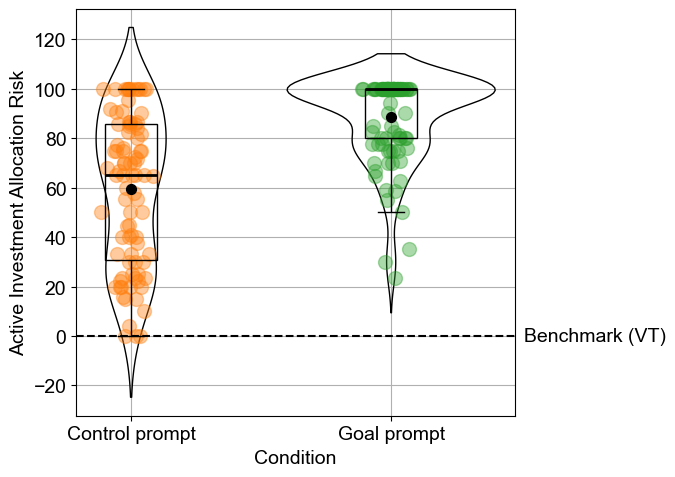

In [41]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond',
    'study3_activeRisk'
)

In [42]:
unused = print_stats(management_data, 'management_weight', 0, 'cond', 'risk-taking')

                sum_sq     df          F        PR(>F)
label     77531.185172    5.0  38.540863  1.639653e-26
Residual  70005.833239  174.0        NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
          group1                    group2          meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------
 (Control prompt, averse) (Control prompt, neutral)  27.7189    0.0  12.7944 42.6435   True
 (Control prompt, averse) (Control prompt, seeking)  51.1734    0.0  36.2489  66.098   True
 (Control prompt, averse)     (Goal prompt, averse)  56.5319    0.0  41.6073 71.4565   True
 (Control prompt, averse)    (Goal prompt, neutral)   54.383    0.0  39.4585 69.3076   True
 (Control prompt, averse)    (Goal prompt, seeking)  55.2579    0.0  40.3333 70.1825   True
(Control prompt, neutral) (Control prompt, seeking)  23.4545 0.0002   8.5299 38.3791   True
(Contro

In [43]:
unused = print_stats(management_data, 'management_weight', 0, 'cond', 'age')

                 sum_sq     df          F        PR(>F)
label      42120.705037    5.0  13.904874  1.973813e-11
Residual  105416.313374  174.0        NaN           NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1               group2        meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------------
(Control prompt, 15) (Control prompt, 30)   -5.883 0.9394 -24.1973 12.4312  False
(Control prompt, 15) (Control prompt, 50)    -15.0 0.1763 -33.3142  3.3143  False
(Control prompt, 15)    (Goal prompt, 15)    24.47 0.0023   6.1557 42.7842   True
(Control prompt, 15)    (Goal prompt, 30)  23.4071 0.0041   5.0928 41.7213   True
(Control prompt, 15)    (Goal prompt, 50)  18.5204 0.0458   0.2062 36.8347   True
(Control prompt, 30) (Control prompt, 50)  -9.1169 0.7059 -27.4312  9.1973  False
(Control prompt, 30)    (Goal prompt, 15)   30.353 0.0001  12.0388 48.6672   True
(Control pro

## Total Expense Risk

In [44]:
fund_identifiers = ter_data['fund'].unique()
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

TtestResult(statistic=-5.226506090284136, pvalue=5.072519991248436e-07, df=168.0)
group1: Control prompt and group2: Goal prompt got t: -5.23, p_value: 0.0, df: 168
group: ('Control prompt',) got t: 5.23 p_value: 0.0 dfs: 80 benchmark: 0.07 d: 0.11
group: ('Goal prompt',) got t: 17.32 p_value: 0.0 dfs: 88 benchmark: 0.07 d: 0.25
means:
cond
Control prompt    0.18
Goal prompt       0.32
Name: ter_weight, dtype: float64
stds:
cond
Control prompt    0.20
Goal prompt       0.14
Name: ter_weight, dtype: float64
cond
Control prompt    81
Goal prompt       89
Name: ter_weight, dtype: int64


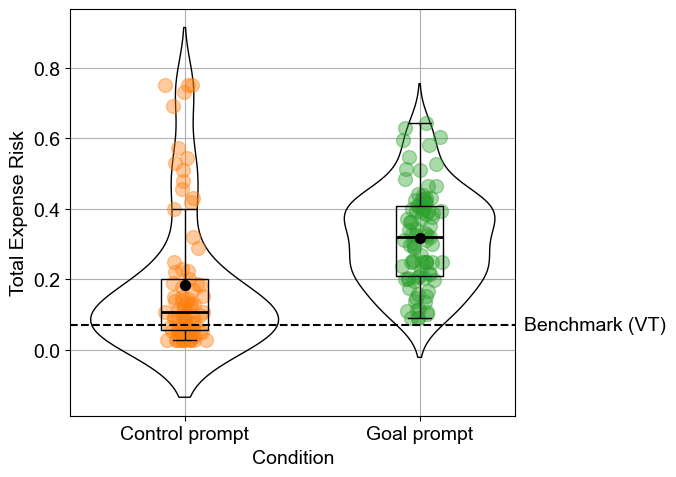

In [45]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond',
    'study3_terRisk'
)

In [46]:
# Control for different N (portfolios being excluded due to no investment in ETFs or mutual funds
ter_control = grouped_ter[grouped_ter['cond'] == 'Control prompt']['ter_weight']
ter_goal = grouped_ter[grouped_ter['cond'] == 'Goal prompt']['ter_weight']

stat, p = stats.mannwhitneyu(ter_control, ter_goal)
print(f'control-goal: {stat}, {p}')

# Perform one-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_control - ter_benchmark)
print(f'control-benchmark: {stat_bench}, {p_bench}')

stat_goal_bench, p_goal_bench = stats.wilcoxon(ter_goal - ter_benchmark)
print(f'goal-benchmark: {stat_goal_bench}, {p_goal_bench}')

# Perform Chi-Square test
count_control = [90-ter_control.size, ter_control.size]
count_goal = [90-ter_goal.size, ter_goal.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_control, count_goal])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

control-goal: 1562.5, 1.8852983533980991e-10
control-benchmark: 615.0, 1.4222826215616325e-06
goal-benchmark: 0.0, 2.534666499693836e-16
chi-square: 5.188235294117648, 0.02274029611529969, df:1


In [47]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'cond', 'risk-taking')

            sum_sq     df          F        PR(>F)
label     1.855964    5.0  16.827859  2.088120e-13
Residual  3.617550  164.0        NaN           NaN
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
          group1                    group2          meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------------------------
 (Control prompt, averse) (Control prompt, neutral)   0.0682 0.4826 -0.0424 0.1788  False
 (Control prompt, averse) (Control prompt, seeking)   0.2903    0.0  0.1684 0.4121   True
 (Control prompt, averse)     (Goal prompt, averse)   0.2352    0.0  0.1246 0.3458   True
 (Control prompt, averse)    (Goal prompt, neutral)    0.235    0.0  0.1235 0.3465   True
 (Control prompt, averse)    (Goal prompt, seeking)   0.2344    0.0  0.1238  0.345   True
(Control prompt, neutral) (Control prompt, seeking)   0.2221    0.0  0.1002 0.3439   True
(Control prompt, neutral)     (Goal p

In [48]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'cond', 'age')

            sum_sq     df         F    PR(>F)
label     0.855330    5.0  6.074857  0.000035
Residual  4.618185  164.0       NaN       NaN
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2        meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------
(Control prompt, 15) (Control prompt, 30)  -0.0371 0.9678 -0.1714 0.0972  False
(Control prompt, 15) (Control prompt, 50)   0.0233 0.9954 -0.1061 0.1527  False
(Control prompt, 15)    (Goal prompt, 15)   0.1069 0.1683 -0.0225 0.2364  False
(Control prompt, 15)    (Goal prompt, 30)   0.1271 0.0538 -0.0012 0.2555  False
(Control prompt, 15)    (Goal prompt, 50)   0.1588 0.0062  0.0305 0.2872   True
(Control prompt, 30) (Control prompt, 50)   0.0604 0.7745 -0.0717 0.1924  False
(Control prompt, 30)    (Goal prompt, 15)    0.144 0.0238   0.012 0.2761   True
(Control prompt, 30)    (Goal prompt, 30)   0.1642 0.0053  0.0

## Trend chasing risk

In [49]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_prepared = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [50]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'

# Open and read the JSON file
with open(json_file_path, 'r') as json_file:
    # Load the JSON data into a dictionary
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
most_traded = []
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    most_traded.append(symbol)
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [51]:
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['cond'] == co]['amount_to_invest']
        top_total = cond[cond['cond'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['cond'] == co]
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3 = top3[top3['ticker_symbol'].isin(most_traded)]
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict

conds = ageRisk['cond'].unique()
ageRisk_cond = ageRisk.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['cond','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(conds, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(conds, top_data)

Control prompt top: % of equities: 0.9999999999999999 and % of total 0.42698998418555617
Control prompt top 3: % of equities: 0.645679012345679 and % of total 0.275698471270427
              cond ticker_symbol  amount_to_invest  pct_of_equities  \
0   Control prompt          AAPL           99000.0         0.244444   
22  Control prompt          TSLA           92500.0         0.228395   
3   Control prompt          AMZN           70000.0         0.172840   

    pct_of_total  
0       0.104375  
22      0.097522  
3       0.073801  

Goal prompt top: % of equities: 1.0 and % of total 0.3272425249169435
Goal prompt top 3: % of equities: 0.233502538071066 and % of total 0.07641196013289037
           cond ticker_symbol  amount_to_invest  pct_of_equities  pct_of_total
51  Goal prompt          TSLA           69000.0         0.233503      0.076412



/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_59173/3554050832.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_59173/3554050832.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_59173/3554050832.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [52]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk-taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [53]:
def calcTopMeans(df, top_dict):
    top_df = None

    for cond, top_assets in top_dict.items():
        filtered_df = df[(df['cond'] == cond) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['cond', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('cond')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

TtestResult(statistic=7.385794501718793, pvalue=5.634624056577284e-12, df=178.0)
group1: Control prompt and group2: Goal prompt got t: 7.39, p_value: 0.0, df: 178
group: ('Control prompt',) got t: 7.58 p_value: 0.0 dfs: 89 benchmark: 9.0 d: 17.94
group: ('Goal prompt',) got t: -1.23 p_value: 0.2209 dfs: 89 benchmark: 9.0 d: -1.37
means:
cond
Control prompt    26.95
Goal prompt        7.63
Name: weight, dtype: float64
stds:
cond
Control prompt    22.46
Goal prompt       10.53
Name: weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: weight, dtype: int64


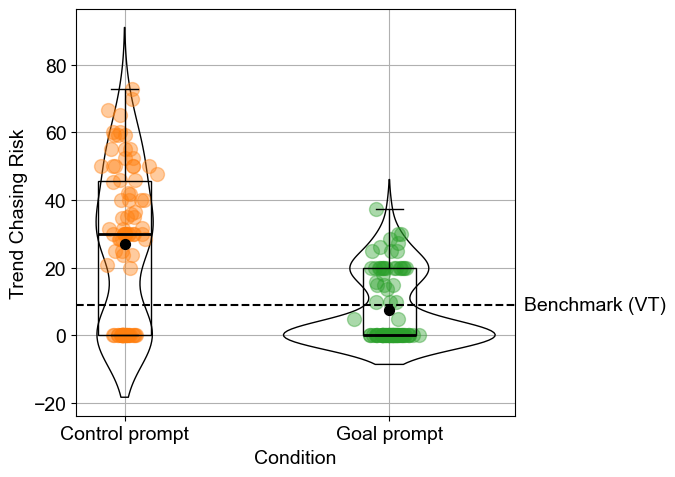

In [54]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond',
    'study3_trendRisk'
)

In [55]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'cond', 'risk-taking')

                sum_sq     df          F        PR(>F)
label     39158.073151    5.0  42.069866  2.917253e-28
Residual  32391.378277  174.0        NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                    group2          meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------------------------------
 (Control prompt, averse) (Control prompt, neutral)  33.8021    0.0  23.6501   43.954   True
 (Control prompt, averse) (Control prompt, seeking)  29.0364    0.0  18.8844  39.1883   True
 (Control prompt, averse)     (Goal prompt, averse)     -5.5 0.6251  -15.652    4.652  False
 (Control prompt, averse)    (Goal prompt, neutral)    5.121 0.6941   -5.031  15.2729  False
 (Control prompt, averse)    (Goal prompt, seeking)   5.2803 0.6655  -4.8717  15.4323  False
(Control prompt, neutral) (Control prompt, seeking)  -4.7657 0.7549 -14.9177   5.3862  Fals

In [56]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'cond', 'age')

                sum_sq     df          F        PR(>F)
label     19085.662332    5.0  12.659799  1.703360e-10
Residual  52463.789096  174.0        NaN           NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
       group1               group2        meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------
(Control prompt, 15) (Control prompt, 30)  -4.5887 0.9095 -17.5088   8.3314  False
(Control prompt, 15) (Control prompt, 50) -11.7767 0.0963 -24.6968   1.1433  False
(Control prompt, 15)    (Goal prompt, 15)  -22.911    0.0 -35.8311   -9.991   True
(Control prompt, 15)    (Goal prompt, 30) -26.4356    0.0 -39.3557 -13.5155   True
(Control prompt, 15)    (Goal prompt, 50)  -24.956    0.0  -37.876 -12.0359   True
(Control prompt, 30) (Control prompt, 50)   -7.188 0.5975 -20.1081    5.732  False
(Control prompt, 30)    (Goal prompt, 15) -18.3223 0.0009 -31.2424  -5.4023   True
(Cont

## Goal attainment (ESG Score)

In [57]:
esg_equities = pd.read_csv('./data/refinitiv/esg_equities_refinitiv.csv', index_col=0)
esg_equities = esg_equities.iloc[1:].reset_index()
esg_equities.columns = ['fund', 'fund_tick', 'esg_score', 'governance_score', 'social_score', 'environmental_score']
esg_equities = esg_equities[['fund', 'esg_score']]

esg_etfs = pd.read_csv('./data/refinitiv/esg_etfs_refinitiv.csv', index_col=0)
esg_etfs = esg_etfs.iloc[1:].reset_index()
esg_etfs.columns = ['fund', 'fund_tick', 'esg_score_auto', 'esg_score']
esg_etfs = esg_etfs[['fund', 'esg_score']]

esg_funds = pd.read_csv('./data/refinitiv/esg_funds_refinitiv.csv', index_col=0)
esg_funds = esg_funds.iloc[1:].reset_index()
esg_funds.columns = ['fund', 'fund_tick', 'esg_score_auto', 'esg_score']
esg_funds = esg_funds[['fund', 'esg_score']]

esg_data = pd.concat([esg_equities, esg_etfs, esg_funds], ignore_index=True)
esg_data['fund'] = esg_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('NULL')
esg_data = esg_data.dropna(subset=['fund'])
esg_data.loc[condition & ~esg_data['esg_score'].isna(), 'esg_score'] = np.nan

In [60]:
esg_identifiers = esg_data['fund'].unique()
def assign_esg_data(row):
    ticker = row['ticker_symbol']
    if ticker in esg_identifiers:
        esg_val = esg_data[esg_data['fund'] == ticker].iloc[0]['esg_score']
        return float(esg_val)
    else: 
        return np.nan

esg_benchmark = float(esg_data[esg_data['fund'] == 'VT'].iloc[0]['esg_score'])

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
filtered_df = filtered_df.copy()
filtered_df['esg'] = filtered_df.apply(assign_esg_data, axis=1)
filtered_df = filtered_df[~filtered_df['esg'].isnull()] # need to exclude rows where we do not have ESG data
filtered_df['esg'] = filtered_df['esg'].astype(float)
esg_df = filtered_df.copy()
esg_df = esg_df.groupby(group_cols).apply(calculate_fund_weight, elem=['ticker_symbol', 'esg']).reset_index()
esg_df['esg_weight'] = esg_df['esg'] * esg_df['weight']
esg_df.head(20)
grouped_esg = esg_df.groupby(group_cols)['esg_weight'].sum().reset_index()

TtestResult(statistic=-0.02287218134085073, pvalue=0.9817778503522308, df=178.0)
group1: Control prompt and group2: Goal prompt got t: -0.02, p_value: 0.9818, df: 178
group: ('Control prompt',) got t: 0.67 p_value: 0.504 dfs: 89 benchmark: 71.12 d: 0.47
group: ('Goal prompt',) got t: 1.08 p_value: 0.2817 dfs: 89 benchmark: 71.12 d: 0.49
means:
cond
Control prompt    71.59
Goal prompt       71.61
Name: esg_weight, dtype: float64
stds:
cond
Control prompt    6.60
Goal prompt       4.25
Name: esg_weight, dtype: float64
cond
Control prompt    90
Goal prompt       90
Name: esg_weight, dtype: int64


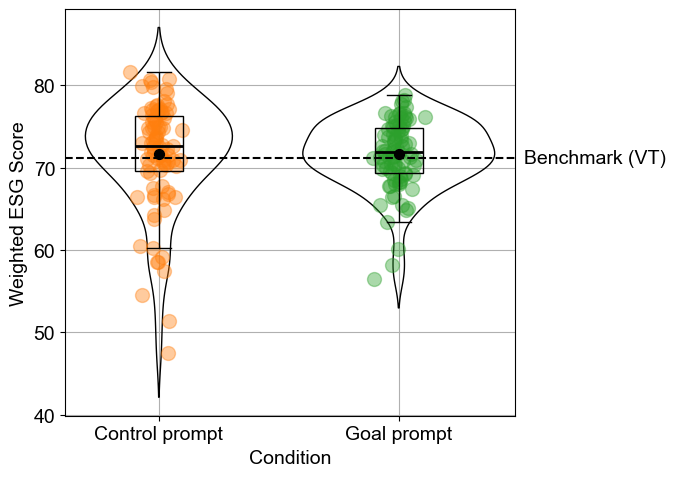

In [61]:
show_benchmark_violinplot(
    grouped_esg, 
    esg_benchmark, 
    'Benchmark (VT)', 
    'esg_weight',
    'Weighted ESG Score', #Top 3 trending equities portfolio share [%]
    'cond',
    'study3_esg'
)

In [62]:
k = len(esg_df['cond'].unique())
N = len(esg_df)
df1 = k - 1
df2 = N - k
print(f"df1: {df1}, df2: {df2}")

df1: 1, df2: 693


In [63]:
esg_control = esg_df[esg_df['cond'] == 'Control prompt']['esg_weight']
esg_goal = esg_df[esg_df['cond'] == 'Goal prompt']['esg_weight']

statistic, p_value = stats.levene(esg_control, esg_goal)

print(f"Statistic: {statistic}, p-value: {p_value}")

Statistic: 23.834037760905883, p-value: 1.3045551662459682e-06


In [64]:
unused = print_stats(grouped_esg, 'esg_weight', esg_benchmark, 'cond', 'risk-taking')

               sum_sq     df          F        PR(>F)
label     1748.721804    5.0  16.286427  3.636995e-13
Residual  3736.578831  174.0        NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
          group1                    group2          meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------------------------
 (Control prompt, averse) (Control prompt, neutral)   1.7108 0.7088  -1.7372  5.1589  False
 (Control prompt, averse) (Control prompt, seeking)  -8.1293    0.0 -11.5773 -4.6812   True
 (Control prompt, averse)     (Goal prompt, averse)  -1.2269 0.9089  -4.6749  2.2211  False
 (Control prompt, averse)    (Goal prompt, neutral)  -1.6154 0.7565  -5.0634  1.8327  False
 (Control prompt, averse)    (Goal prompt, seeking)  -3.5194 0.0425  -6.9674 -0.0713   True
(Control prompt, neutral) (Control prompt, seeking)  -9.8401    0.0 -13.2881 -6.3921   True
(Control p

In [65]:
unused = print_stats(grouped_esg, 'esg_weight', esg_benchmark, 'cond', 'age')

               sum_sq     df         F    PR(>F)
label      177.866081    5.0  1.166239  0.327729
Residual  5307.434554  174.0       NaN       NaN
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2        meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------------
(Control prompt, 15) (Control prompt, 30)  -0.7035 0.9964 -4.8129 3.4059  False
(Control prompt, 15) (Control prompt, 50)  -2.4366 0.5279  -6.546 1.6728  False
(Control prompt, 15)    (Goal prompt, 15)   0.2529    1.0 -3.8565 4.3623  False
(Control prompt, 15)    (Goal prompt, 30)  -1.2664 0.9489 -5.3758  2.843  False
(Control prompt, 15)    (Goal prompt, 50)  -2.0698 0.6954 -6.1792 2.0395  False
(Control prompt, 30) (Control prompt, 50)  -1.7331 0.8289 -5.8425 2.3762  False
(Control prompt, 30)    (Goal prompt, 15)   0.9564 0.9849  -3.153 5.0658  False
(Control prompt, 30)    (Goal prompt, 30)  -0.5629 0.

## MANOVA

In [66]:
geo_us.rename(columns={'weight': 'us_weight'}, inplace=True)
trends_data.rename(columns={'weight': 'trends_weight'}, inplace=True)
print(geo_us.shape)
print(sec.shape)
print(management_data.shape)
print(grouped_ter.shape)
print(trends_data.shape)
print(grouped_esg.shape)

(180, 9)
(180, 7)
(180, 10)
(170, 6)
(180, 6)
(180, 6)


In [67]:
df_metrics = geo_us.merge(
    sec[['cond', 'age', 'risk-taking', 'iteration', 'concentration']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    management_data[['cond', 'age', 'risk-taking', 'iteration', 'management_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_ter[['cond', 'age', 'risk-taking', 'iteration', 'ter_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    trends_data[['cond', 'age', 'risk-taking', 'iteration', 'trends_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_esg[['cond', 'age', 'risk-taking', 'iteration', 'esg_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.dropna()
print(df_metrics.shape)




(170, 14)


In [68]:
df_metrics.rename(columns={'risk-taking': 'risk_taking'}, inplace=True)

In [69]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ cond', data = df_metrics)
print(manova.mv_test())

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ cond + risk_taking + age', data = df_metrics)
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0200 5.0000 164.0000 1608.1177 0.0000
         Pillai's trace  0.9800 5.0000 164.0000 1608.1177 0.0000
 Hotelling-Lawley trace 49.0280 5.0000 164.0000 1608.1177 0.0000
    Roy's greatest root 49.0280 5.0000 164.0000 1608.1177 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
             cond          Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.3221 5.0000 164.0000 69.0289 0.0000
            Pillai's trace 0.6779 5.0000 164.

In [70]:
group_levels = df_metrics['cond'].unique()

# Run MANOVA separately for each level of "cond"
for level in group_levels:
    subset = df_metrics[df_metrics['cond'] == level]  # Subset data for a specific group level
    
    print(f"\nMANOVA for cond: {level}")
    manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ risk_taking + age', data=subset)
    print(manova.mv_test())


MANOVA for cond: Control prompt
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0193 5.0000 73.0000 740.5130 0.0000
         Pillai's trace  0.9807 5.0000 73.0000 740.5130 0.0000
 Hotelling-Lawley trace 50.7201 5.0000 73.0000 740.5130 0.0000
    Roy's greatest root 50.7201 5.0000 73.0000 740.5130 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
      risk_taking       Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1950 10.0000 146.0000 18.4630 0.0000
         Pillai's trace 1.1016 10.0000 14

## Plotting

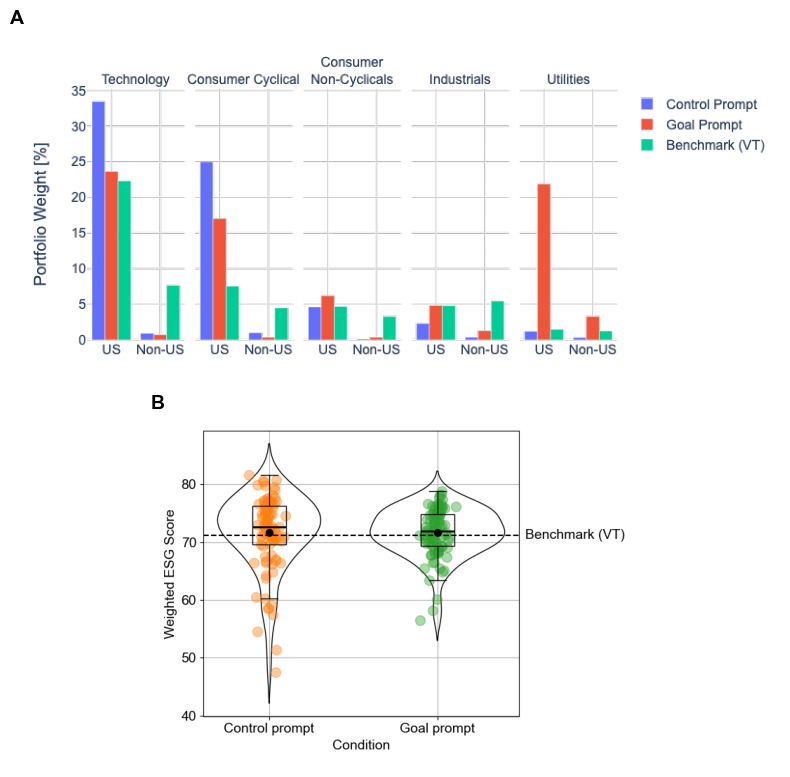

In [90]:
from matplotlib.gridspec import GridSpec
from PIL import Image

img1 = Image.open('./figures/concentration.png')
img2 = Image.open('./figures/study3_esg.png')

fig = plt.figure(figsize=(9, 8))

gs = GridSpec(2, 1, height_ratios=[1.1, 1])

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

ax1.imshow(img1)
ax1.set_title("A", fontweight='bold', loc='left', fontsize=14, fontfamily='Arial')
ax1.axis("off")

ax2.imshow(img2)
ax2.set_title("B", fontweight='bold', loc='left', fontsize=14, fontfamily='Arial')
ax2.axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace= 0)

plt.savefig('./figures/study3_panels.png')

plt.show()